# Anti-Reflective Coating: BBAR Optimization
Designing a Broadband Anti-Reflective (BBAR) coating to minimize reflection from a glass surface.

## Introduction

Uncoated glass reflects about 4% of incident light per surface due to the refractive index mismatch between air ($n \approx 1$) and glass ($n \approx 1.5$). In multi-element optical systems, these losses accumulate and cause ghost images.

This tutorial demonstrates:
1.  **Baseline Analysis**: The reflection of a bare glass surface (Fresnel reflection).
2.  **BBAR Design**: Creating a 4-layer Anti-Reflective coating using $MgF_2$ and $TiO_2$.
3.  **Performance Comparison**: Visually and numerically comparing the coated vs. uncoated surface.
4.  **Angular Stability**: Evaluating performance at oblique angles of incidence ($0^\circ, 30^\circ, 60^\circ$).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from optiland import optic
from optiland.materials import Material, IdealMaterial
from optiland.thin_film import ThinFilmStack
from optiland.coatings import ThinFilmCoating, FresnelCoating

## 1. Materials & Baseline Setup

We define the materials and the reference wavelength ($\lambda = 550$ nm).

In [6]:
# Define Materials
air = IdealMaterial(n=1.0)
glass = Material("N-BK7", reference="SCHOTT")
mgf2 = Material("MgF2", reference="Li")    # Low Index (~1.38)
tio2 = Material("TiO2", reference="Siefke") # High Index (~2.5)

# Setup wavelength range (Visible Spectrum)
wavelengths = np.linspace(0.45, 0.7, 301) # 450-700 nm in µm

# Baseline: Uncoated Glass (Fresnel Reflection)
# We use FresnelCoating to simulate the bare interface
bare_surface = FresnelCoating(air, glass)

## 2. Design the BBAR Stack

We implement a 4-layer BBAR design (LHLH structure).
Crucially, the first layer facing air must be the Low Index material to avoid large reflections.

**Stack Recipe (Air $\rightarrow$ Glass):**
1.  **MgF2** (94 nm) - Low Index (Outer Layer)
2.  **TiO2** (117 nm) - High Index
3.  **MgF2** (38 nm) - Low Index (Thin)
4.  **TiO2** (14 nm) - High Index (Inner Matching Layer)

This structure is optimized to suppress reflection across the visible spectrum (400-700nm).

In [7]:
# Create the Stack
bbar_stack = ThinFilmStack(incident_material=air, substrate_material=glass)

# Add layers (incident -> substrate)
# Start with Low Index (MgF2) facing Air to minimize first surface reflection.
# Thicknesses (um): ~94nm, ~117nm, ~38nm, ~14nm
# This is an optimized structure for 400-700nm.
bbar_stack.add_layer(mgf2, 0.094, "L1 (Outer)")
bbar_stack.add_layer(tio2, 0.117, "H1")
bbar_stack.add_layer(mgf2, 0.038, "L2")
bbar_stack.add_layer(tio2, 0.014, "H2 (Inner)")

# Create the Coating Object
bbar_coating = ThinFilmCoating(air, glass, bbar_stack)

# Inspect the design
print(bbar_stack)

ThinFilmStack Summary
---------------------
Incident:  IdealMaterial
Substrate: N-BK7
Layers:
  1. MgF2 (94.0 nm)
  2. TiO2 (117.0 nm)
  3. MgF2 (38.0 nm)
  4. TiO2 (14.0 nm)
---------------------
Total Thickness: 263.0 nm


## 3. Spectral Performance Analysis

We compare the Reflectance ($R$) of the BBAR coating against the bare glass baseline at normal incidence ($0^\circ$).

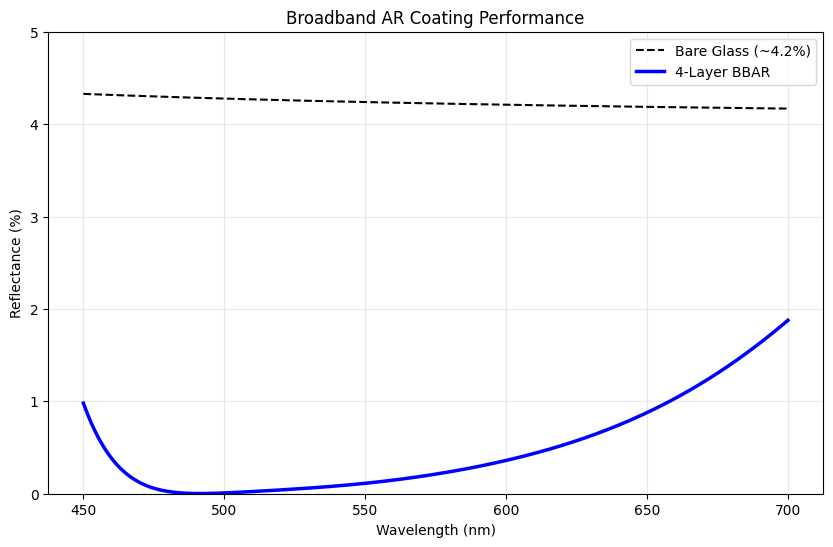

Average Reflectance (400-700nm): 0.48%


In [8]:
# Compute Reflectance for BBAR
R_bbar = bbar_stack.compute_rtRTA(wavelengths, aoi_rad=0.0, polarization="u")["R"]

# Compute Reflectance for Bare Glass
# We calculate theoretical Fresnel reflection for comparison
n_glass = glass.n(wavelengths)
R_glass = ((1.0 - n_glass) / (1.0 + n_glass))**2

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(wavelengths * 1000, R_glass * 100, 'k--', linewidth=1.5, label="Bare Glass (~4.2%)")
plt.plot(wavelengths * 1000, R_bbar * 100, 'b-', linewidth=2.5, label="4-Layer BBAR")

plt.title("Broadband AR Coating Performance")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 5)
plt.show()

avg_R_bbar = np.mean(R_bbar) * 100
print(f"Average Reflectance (400-700nm): {avg_R_bbar:.2f}%")

## 4. System Transmission Comparison: BBAR vs Fresnel

In this section, we compare the total transmission of the lens system coated with our custom BBAR stack versus a standard Fresnel (uncoated) system. We will visualize the pupil transmission map for both cases.

In [9]:
from optiland.rays import PolarizationState

class CoatedDoublet(optic.Optic):
    def __init__(self, coating=None):
        super().__init__()

        self.add_surface(index=0, radius=np.inf, thickness=np.inf)
        self.add_surface(
            index=1,
            radius=29.32908,
            thickness=0.7,
            material="N-BK7",
            is_stop=True,
            coating=coating,
        )
        self.add_surface(index=2, radius=-20.06842, thickness=0.032, coating=coating)
        self.add_surface(
            index=3,
            radius=-20.08770,
            thickness=0.5780,
            material=("SF2", "schott"),
            coating=coating,
        )
        self.add_surface(index=4, radius=-66.54774, thickness=47.3562, coating=coating)
        self.add_surface(index=5)

        self.set_aperture(aperture_type="imageFNO", value=8.0)

        self.set_field_type(field_type="angle")
        self.add_field(y=0.0)
        self.add_field(y=0.7)
        self.add_field(y=1.0)

        self.add_wavelength(value=0.4861)
        self.add_wavelength(value=0.5876, is_primary=True)
        self.add_wavelength(value=0.6563)

        self.update_paraxial()
        self.image_solve()

        # Set Polarization (Required for ThinFilmCoating)
        state = PolarizationState(is_polarized=False)
        self.set_polarization(state)

# 1. System with BBAR Coating
lens_bbar = CoatedDoublet(coating=bbar_coating)
rays_bbar = lens_bbar.trace(Hx=0, Hy=0, wavelength=0.55, num_rays=256, distribution="uniform")
intensity_bbar = rays_bbar.i

# 2. System with Standard Fresnel Surface (Air/Glass Refraction)
# We use a FresnelCoating to simulate the standard reflection loss at each interface (~4%)
fresnel_coating = FresnelCoating(air, glass)
lens_fresnel = CoatedDoublet(coating=fresnel_coating)
rays_fresnel = lens_fresnel.trace(Hx=0, Hy=0, wavelength=0.55, num_rays=256, distribution="uniform")
intensity_fresnel = rays_fresnel.i

print(f"Average Transmission (BBAR Coated): {np.mean(intensity_bbar):.4f}")
print(f"Average Transmission (Fresnel Uncoated): {np.mean(intensity_fresnel):.4f}")
print(f"Improvement: {(np.mean(intensity_bbar) - np.mean(intensity_fresnel)) / np.mean(intensity_fresnel) * 100:.1f}%")

Average Transmission (BBAR Coated): 0.9948
Average Transmission (Fresnel Uncoated): 0.8087
Improvement: 23.0%


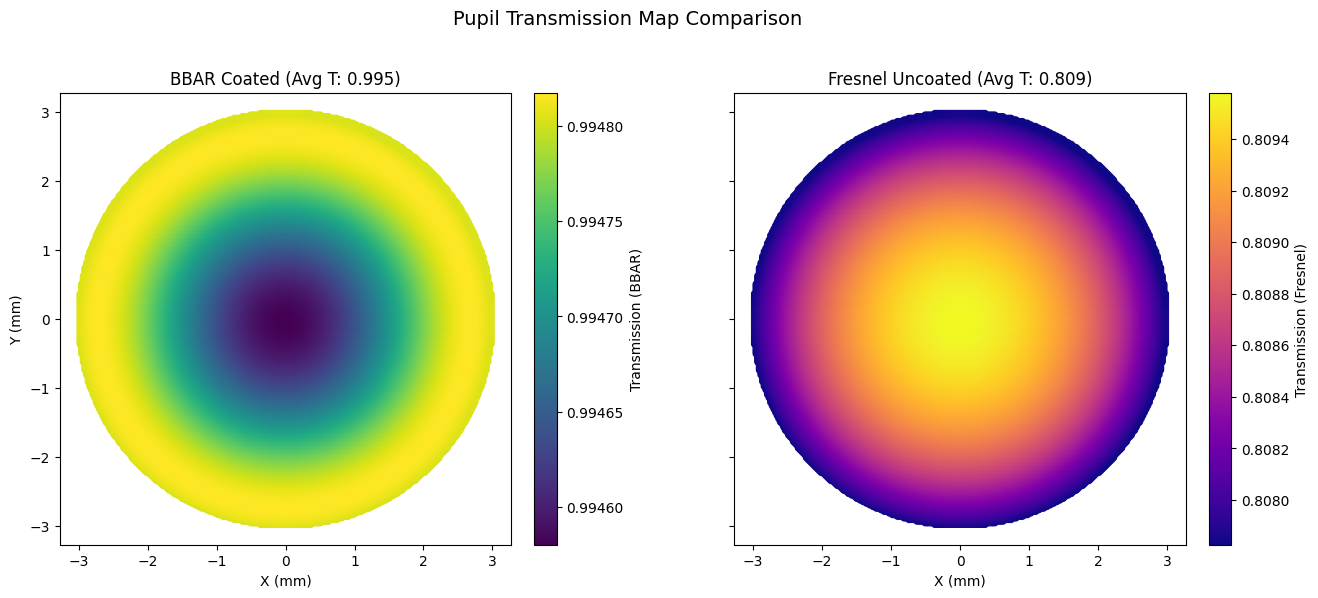

In [ ]:
# Get pupil coordinates (Stop is at surface 1)
x_stop_bbar = lens_bbar.surface_group.x[1, :]
y_stop_bbar = lens_bbar.surface_group.y[1, :]

x_stop_fresnel = lens_fresnel.surface_group.x[1, :]
y_stop_fresnel = lens_fresnel.surface_group.y[1, :]

# Comparative visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Plot BBAR coated (own scale + own colorbar)
sc1 = axes[0].scatter(
    x_stop_bbar,
    y_stop_bbar,
    c=intensity_bbar,
    s=20,
    cmap="plasma",
    vmin=np.min(intensity_bbar),
    vmax=np.max(intensity_bbar),
)
axes[0].set_title(f"BBAR Coated (Avg T: {np.mean(intensity_bbar):.3f})")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("X (mm)")
axes[0].set_ylabel("Y (mm)")
cbar1 = fig.colorbar(sc1, ax=axes[0], orientation="vertical", fraction=0.046, pad=0.04)
cbar1.set_label("Transmission (BBAR)")

# Plot Fresnel uncoated (own scale + own colorbar)
sc2 = axes[1].scatter(
    x_stop_fresnel,
    y_stop_fresnel,
    c=intensity_fresnel,
    s=20,
    cmap="plasma",
    vmin=np.min(intensity_fresnel),
    vmax=np.max(intensity_fresnel),
)
axes[1].set_title(f"Fresnel Uncoated (Avg T: {np.mean(intensity_fresnel):.3f})")
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("X (mm)")
cbar2 = fig.colorbar(sc2, ax=axes[1], orientation="vertical", fraction=0.046, pad=0.04)
cbar2.set_label("Transmission (Fresnel)")

plt.suptitle("Pupil Transmission Map Comparison", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()